In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from tools.streamlines_to_quad_faces import QuadFaceGenerator
from torch_geometric.data import Data
from collections import defaultdict

In [2]:
from tools import StreamlinePostProcessor
from tools.streamline_intersection_splitter import StreamlineIntersectionSplitter
from tools import MeshCheck

In [3]:
def plt_streamlines(mesh, output_file="./figures/streamlines.png", colored=False):
    import matplotlib.pyplot as plt
    import numpy as np

    streamlines = mesh.streamlines

    # Create a figure for plotting
    plt.figure(figsize=(5, 5))

    # color = 'r'
    for streamline in streamlines:

        color = np.random.rand(3)
        streamline = np.array(streamline)  # Convert to numpy array for easier plotting
        start = streamline[0, :]
        end = streamline[-1, :]
        plt.plot(streamline[:, 0], streamline[:, 1], color=color)

    # plt.axis('off')
    plt.axis('equal')  # Equal aspect ratio
    plt.tight_layout()
    # plt.savefig(output_file, dpi=300, transparent=True)



In [4]:
def plt_mesh(mesh):
    plt.figure()
    nodes = mesh.x
    faces = mesh.faces
    streamline_mapping = mesh.edge_to_streamline

    num_edges_each_faces = faces.size(0)
    
    for i,face in enumerate(faces.T):
        streamlines = []
        rand_color = np.random.rand(3,)
        for j in range(num_edges_each_faces):
            edge_idx1 =j
            edge_idx2 =(j+1)%num_edges_each_faces
            node1 = nodes(face[edge_idx1])
            node2 = nodes(face[edge_idx2])
            
            surface = np.vstack(streamlines)
            plt.plot([node1[0],node2[0]],[node1[1],node2[1]],color = 'k')
    
    

In [5]:
def plt_faces(mesh):
    plt.figure()
    nodes = mesh.blocking_nodes
    faces = mesh.blocking_faces
    streamline_mapping = mesh.edge_to_streamline

    num_edges_each_faces = faces.size(0)
    
    for i,face in enumerate(faces.T):
        streamlines = []
        rand_color = np.random.rand(3,)
        for j in range(num_edges_each_faces):
            edge_idx1 =j
            edge_idx2 =(j+1)%num_edges_each_faces

            edge = (face[edge_idx1].item(),face[edge_idx2].item())
            streamline = streamline_mapping[edge]
            streamlines.append(streamline)
            
        surface = np.vstack(streamlines)
        plt.fill(surface[:,0],surface[:,1],color = rand_color)
    
    plt.scatter(nodes[:,0],nodes[:,1],color = 'r')

In [6]:
def plt_recon_streamlines(mesh):
    plt.figure()
    nodes = mesh.blocking_nodes
    faces = mesh.blocking_faces
    streamline_mapping = mesh.edge_to_streamline
    recon_edge_to_streamline =mesh.recon_edge_to_streamline
    num_edges_each_faces = faces.size(0)
    
    for i,face in enumerate(faces.T):

        for j in range(num_edges_each_faces):
            edge_idx1 =j
            edge_idx2 =(j+1)%num_edges_each_faces

            edge = (face[edge_idx1].item(),face[edge_idx2].item())
            
            streamline = streamline_mapping[edge]
            recon_streamline = recon_edge_to_streamline[edge]

            plt.plot(streamline[:, 0], streamline[:, 1], color='red')
            plt.plot(recon_streamline[:, 0], recon_streamline[:, 1], color='blue')
            



In [7]:
def plt_recon_faces(mesh):
    plt.figure()
    nodes = mesh.blocking_nodes
    faces = mesh.blocking_faces
    streamline_mapping = mesh.recon_edge_to_streamline

    num_edges_each_faces = faces.size(0)
    
    for i,face in enumerate(faces.T):
        streamlines = []
        rand_color = np.random.rand(3,)
        for j in range(num_edges_each_faces):
            edge_idx1 =j
            edge_idx2 =(j+1)%num_edges_each_faces

            edge = (face[edge_idx1].item(),face[edge_idx2].item())
            streamline = streamline_mapping[edge]
            streamlines.append(streamline)
            
        surface = np.vstack(streamlines)
        plt.fill(surface[:,0],surface[:,1],color = rand_color)
    
    plt.scatter(nodes[:,0],nodes[:,1],color = 'r')

In [8]:
def plt_face_node_vector(mesh):

    faces = mesh.blocking_faces
    nodes = mesh.blocking_nodes
    streamline_mapping = mesh.edge_to_streamline
    node_face_angle_mapping = mesh.node_face_angle_mapping
    plt.figure()
    
    for face_id,face in enumerate(faces.T):
        for j in range(4):
            edge_idx1 = j
            edge_idx2 = (j+1) % 4  # num_edges_each_faces = 4

            node_idx1 = face[edge_idx1].item()
            node_idx2 = face[edge_idx2].item()
            edge = (node_idx1, node_idx2)

            node1 = nodes[node_idx1, 0:2]
            node2 = nodes[node_idx2, 0:2]

            streamline = torch.from_numpy(streamline_mapping[edge].copy())
            plt.plot(streamline[:, 0], streamline[:, 1],'k-',alpha=0.5)  # Streamline plotten

            # Winkel korrekt abrufen
            a_out = node_face_angle_mapping[(node_idx1, face_id)]['angle_out']
            a_in = node_face_angle_mapping[(node_idx2, face_id)]['angle_in']  # IN nicht OUT!

            length = 0.15 * torch.linalg.norm(node1 - node2)

            # KORRIGIERT: cos/sin vertauscht, dy2 existiert nicht
            dx_out = length * torch.cos(a_out)  # cos für x
            dy_out = length * torch.sin(a_out)  # sin für y

            dx_in = length * torch.cos(a_in)
            dy_in = length * torch.sin(a_in)

            # OUT vector (grün)
            dX_out = [node1[0], node1[0] + dx_out]
            dY_out = [node1[1], node1[1] + dy_out]
            plt.plot(dX_out, dY_out, 'g-', linewidth=2, label='OUT' if j == 0 else "")

            # IN vector (blau)
            dX_in = [node2[0], node2[0] + dx_in]
            dY_in = [node2[1], node2[1] + dy_in]
#             plt.plot(dX_in, dY_in, 'b-', linewidth=2, label='IN' if j == 0 else "")

            # Nodes markieren
            plt.scatter([node1[0], node2[0]], [node1[1], node2[1]], c='red', s=50)

    plt.axis('equal')
#     plt.legend()
    plt.show()

In [9]:
def edge_to_streamline_mapping(meshes):

    updated_data = []
    splitter     = StreamlineIntersectionSplitter(offset_boundingBox=0.05, num_samples=5)

    for i in range(len(meshes)):
    
        try:
            mesh = meshes[i]
            tri_mesh = Data(x= mesh.tri_coordinates,faces = mesh.tri_faces)
            quad_mesh = Data(x= mesh.quad_coordinates,faces = mesh.quad_faces)
            mesh_check = MeshCheck(tri_mesh, quad_mesh, tol=5e-4)
            
            if mesh_check.is_valid:
                updated_streamlines = splitter.process_streamlines(mesh.streamlines)
                faceGenerator       = QuadFaceGenerator(updated_streamlines)
                mesh.streamlines_init = mesh.streamlines
                mesh.streamlines = updated_streamlines
                faces, edge_to_streamline, edge_index, nodes = faceGenerator.get_data()

                mesh.edge_to_streamline = edge_to_streamline
                mesh.blocking_faces     = faces
                mesh.blocking_nodes     = nodes

                updated_data.append(mesh)
#             else:
#                 print('not valid tri -> quad mesh transformation')
        except :
            print(f'failed ad id {i}')
    return updated_data


In [10]:
def face_node_angle_mapping(meshes):
    
    for i, mesh in enumerate(meshes):


        nodes = mesh.blocking_nodes
        faces = mesh.blocking_faces
        
        streamline_mapping      = mesh.edge_to_streamline
        node_face_angle_mapping = defaultdict(dict) 
        num_edges_each_faces    = faces.size(0)
        
        
        for id_face in range(faces.size(1)):
            face = faces[:,id_face]
            for j in range(num_edges_each_faces):
                edge_idx1 =j
                edge_idx2 =(j+1)%num_edges_each_faces

                node_idx1 = face[edge_idx1].item()
                node_idx2 =face[edge_idx2].item()
                edge       = (node_idx1,node_idx2)

                streamline = torch.from_numpy(streamline_mapping[edge].copy())
                dx1 = streamline[3,0] - streamline[0,0]
                dy1 = streamline[3,1] - streamline[0,1]

                dx2 = streamline[-1,0] - streamline[-3,0]
                dy2 = streamline[-1,1] - streamline[-3,1]
                alpha = torch.atan2(dy1,dx1)
                beta = torch.atan2(dy2,dx2)

                node_face_angle_mapping[(node_idx1,id_face)]['angle_out'] = alpha
                node_face_angle_mapping[(node_idx2,id_face)]['angle_in'] = beta

            meshes[i].node_face_angle_mapping = node_face_angle_mapping
    return meshes
    

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicHermiteSpline

def reconstruct_face_with_splines(mesh, num_points=100):
    """
    Rekonstruiert ein Face mithilfe kubischer Hermite-Splines.
    Die Steigungen an den Nodes werden durch die gespeicherten Winkel bestimmt.
    """
    
    faces = mesh.blocking_faces
    nodes = mesh.blocking_nodes
    node_face_angle_mapping = mesh.node_face_angle_mapping
    recon_edge_to_streamline= defaultdict(dict) 

    reconstructed_edges = []
    face_nodes = []
    
    for i in range(faces.size(1)):
        face_id = i
        face = faces[:,face_id]
        for j in range(4):  # 4 Kanten pro quadrilaterales Face
            edge_idx1 = j
            edge_idx2 = (j + 1) % 4

            node_idx1 = face[edge_idx1].item()
            node_idx2 = face[edge_idx2].item()
            edge = (node_idx1,node_idx2)
            # Node-Koordinaten
            node1 = nodes[node_idx1, 0:2].numpy()
            node2 = nodes[node_idx2, 0:2].numpy()
            face_nodes.extend([node1, node2])

            # Winkel aus dem mapping abrufen
            try:
                a_out = node_face_angle_mapping[(node_idx1, face_id)]['angle_out'].item()
                a_in = node_face_angle_mapping[(node_idx2, face_id)]['angle_in'].item()
            except KeyError as e:
                print(f"KeyError für Face {face_id}, Edge {node_idx1}->{node_idx2}: {e}")
                continue

            # Steigungsvektoren aus Winkeln berechnen
            # Die Magnitude wird durch die Distanz zwischen den Nodes skaliert
            distance = np.linalg.norm(node2 - node1)
            scale_factor = distance * 0.3  # Skalierungsfaktor für die Steigungen

            derivative1 = np.array([np.cos(a_out), np.sin(a_out)]) * scale_factor
            derivative2 = np.array([np.cos(a_in), np.sin(a_in)]) * scale_factor

            # Parametrische Darstellung: t ∈ [0, 1]
            t = np.linspace(0, 1, num_points)

            # Kubischer Hermite-Spline für x- und y-Koordinaten separat
            x_points = np.array([node1[0], node2[0]])
            y_points = np.array([node1[1], node2[1]])
            x_derivatives = np.array([derivative1[0], derivative2[0]])
            y_derivatives = np.array([derivative1[1], derivative2[1]])

            # Splines erstellen
            t_nodes = np.array([0, 1])
            spline_x = CubicHermiteSpline(t_nodes, x_points, x_derivatives)
            spline_y = CubicHermiteSpline(t_nodes, y_points, y_derivatives)

            # Spline-Punkte berechnen
            x_spline = spline_x(t)
            y_spline = spline_y(t)

            spline_points = np.column_stack([x_spline, y_spline])
            recon_edge_to_streamline[edge]=spline_points
    mesh.recon_edge_to_streamline = recon_edge_to_streamline
    
    return mesh
    

In [12]:
def get_starting_nodes(meshes):
    updated_meshes = []
    for mesh in meshes:
        tri_coords       = mesh.tri_coordinates
        mask_start_nodes = tri_coords[:,2]==0
        start_nodes      = tri_coords[mask_start_nodes,0:2]
        quad_block_coords =  torch.round(mesh.blocking_nodes[:,0:2],decimals = 12)
        start_nodes_ids = []
        for i,node in enumerate(start_nodes):
            distance = torch.linalg.norm(quad_block_coords-node,dim=1)
            min_idx  = torch.argmin(distance)
            start_nodes_ids.append(min_idx.item())

        mesh.start_nodes = start_nodes_ids
        updated_meshes.append(mesh)
    return updated_meshes

In [13]:
def calculate_angles_sorted_normalized(meshes, tol=1e-6):
    
    updated_data = []
    for mesh in meshes:
        is_valid = True
        start_features = torch.zeros(len(mesh.start_nodes), 4)

        for i, start_id in enumerate(mesh.start_nodes):

            node = mesh.blocking_nodes[start_id, :]
            start_features[i, 0:2] = node


            angles_at_node = []

            for j, streamline in enumerate(mesh.streamlines_init):
                if j==6:
                    #Only first 6 streamlines are part of the geometry
                    break

                distance_start = torch.linalg.norm(torch.from_numpy(streamline[0].copy())-node)
                distance_end = torch.linalg.norm(torch.from_numpy(streamline[-1].copy())-node)

                if distance_start.item() <tol :

                    dx = torch.tensor(streamline[1,0]-streamline[0,0])
                    dy = torch.tensor(streamline[1,1]-streamline[0,1])
                    angles_at_node.append((torch.atan2(dy,dx)+torch.pi)/(2*torch.pi))

                if distance_end.item() <tol :

                    dx = torch.tensor(streamline[-2,0]-streamline[-1,0])
                    dy = torch.tensor(streamline[-2,1]-streamline[-1,1])
                    angles_at_node.append( (torch.atan2(dy,dx)+torch.pi)/(2*torch.pi))
            if len(angles_at_node) == 0:
                is_valid = False
                print('error no angle found')
            elif len(angles_at_node) == 1:
                is_valid = False
                print('error only angle found')

            elif len(angles_at_node) == 2:
                angles_sorted = sorted(angles_at_node)
                start_features[i, 2] = angles_sorted[0]  
                start_features[i, 3] = angles_sorted[1]
                
            else:
                print('too many angles found')
                is_valid = False
        if is_valid:
            mesh.start_features = start_features
            updated_data.append(mesh)
        
    return updated_data

In [14]:
def read_all_data():
    
    base_directory = './saved_meshes_clean/'
    sub_directory  = os.listdir(base_directory)

    data = []

    for i in range(len(sub_directory)):

        directory = sub_directory[i]
        print(directory)

        if not directory.endswith('.pt'):
            path_dir = base_directory + directory
            files = os.listdir(path_dir)
            temp_data = []
            for file in files:
                if file.endswith('.pt'):
                    path = path_dir+'/' + file
                    load_data = torch.load(path)
                    temp_data += load_data

            updated_data = edge_to_streamline_mapping(temp_data)
            updated_data = face_node_angle_mapping(updated_data)
            updated_data = get_starting_nodes(updated_data)
            updated_data = calculate_angles_sorted_normalized(updated_data)
            data += (updated_data)
            print(f'num updated_data: {len(updated_data)}, num total: {len(data)}')

    return data

In [15]:
data = read_all_data()

checkpoints_mars_v1
num updated_data: 56, num total: 56
checkpoints_v6
num updated_data: 10, num total: 66
checkpoints_mars_v2
num updated_data: 20, num total: 86
checkpoints_snickers
error no angle found
error no angle found
error no angle found
error no angle found
num updated_data: 896, num total: 982
checkpoints
num updated_data: 18, num total: 1000
checkpoints_mars
num updated_data: 69, num total: 1069
checkpoints_v7
num updated_data: 3, num total: 1072


In [27]:
save = True
load = False
path = 'data_domain_partition_v2.pt'
if save == True:
    torch.save(data,path)
if load == True:
    updated_data = torch.load(path)

In [14]:
data = torch.load('data_domain_partition.pt')

succsess: True


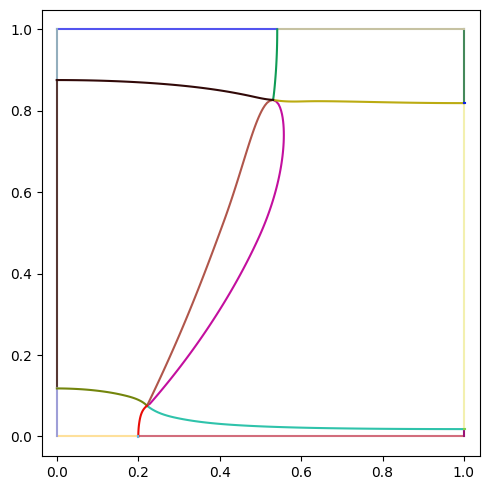

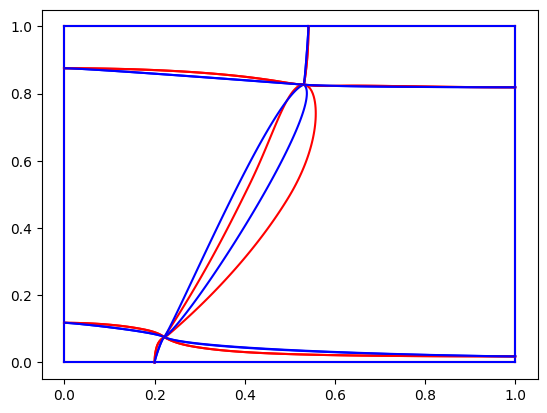

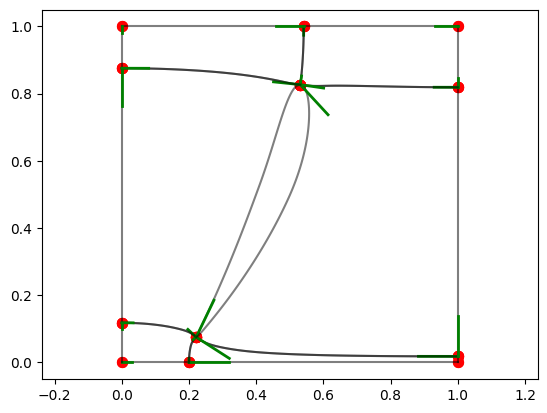

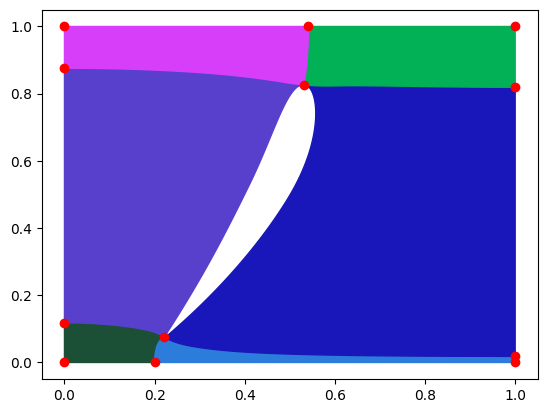

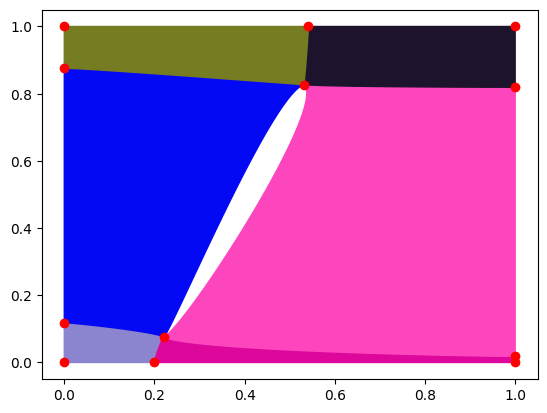

In [25]:
# ## Testing
rand_id   = np.random.randint(len(data)-1)
test_mesh = data[rand_id]

tri_mesh  = Data(x= test_mesh.tri_coordinates,faces = test_mesh.tri_faces)
quad_mesh = Data(x= test_mesh.quad_coordinates,faces = test_mesh.quad_faces)
mesh_check                  = MeshCheck(tri_mesh, quad_mesh, tol=5e-4)
print(f'succsess: {mesh_check.is_valid}')


test_mesh = reconstruct_face_with_splines(test_mesh)
plt_streamlines(test_mesh)
plt_recon_streamlines(test_mesh)

plt_face_node_vector(test_mesh)

plt_faces(test_mesh)
plt_recon_faces(test_mesh)